# Batch Unconstraining Results Analysis (Product Level)

This notebook evaluates the performance of different unconstraining models (Naive, EM, MARSS, EM-X Price, MARSS-X Price) across multiple cargo segments and calculates global aggregate performance.

In [1]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

FILTER_ZEROS = False
THRESHOLD = 1
SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]
MODELS = ["Naive", "EM", "MARSS", "EMXPrice", "MARSSXPrice"]

In [2]:
files = glob.glob("./unconstrained_results/*.parquet")

df_all = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print(f"Loaded {len(files)} files. Shape: {df_all.shape}")
df_all.head()

Loaded 84 files. Shape: (294147, 137)


,Date,Origin,Destination,Flight_Sequence,Scheduled_Flights,Base_Price_per_kg,Price_Index,Final_True_Demand,Final_Constrained_Bookings,Is_Censored,...,Naive_Express_Est,EM_Express_Est,MARSS_Express_Est,EMXPrice_Express_Est,MARSSXPrice_Express_Est,Naive_Spot_Est,EM_Spot_Est,MARSS_Spot_Est,EMXPrice_Spot_Est,MARSSXPrice_Spot_Est
0,2016-01-01,CAN,CGO,1,1,2.6,1.069582,17032.0,17032.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,CAN,CGO,1,1,2.6,0.857691,13062.0,13062.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,CAN,CGO,1,1,2.6,0.911895,9018.0,9018.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,CAN,CGO,1,1,2.6,0.809621,15408.0,15408.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-05,CAN,CGO,1,1,2.6,1.128755,17773.0,17773.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def trim_burn_in(df_group):
    # Check for NaNs in any of the estimation columns across segments
    # All models share the same LOOKBACK=365
    est_cols = [f"{m}_{s}_Est" for m in MODELS for s in SEGMENTS]
    valid_mask = df_group[est_cols].notna().all(axis=1)
    
    if not valid_mask.any():
        return pd.DataFrame()
        
    first_valid_idx = valid_mask.idxmax() 
    return df_group.loc[first_valid_idx:].copy()

print("Trimming burn-in period...")
df_trimmed = df_all.groupby(['Origin', 'Destination'], as_index=False, group_keys=False).apply(trim_burn_in)

print("Calculating Total metrics across all segments...")
for m in MODELS:
    total_est_col = f"{m}_Total_Est"
    df_trimmed[total_est_col] = 0.0
    
df_trimmed["Total_Oracle_kg"] = 0.0
df_trimmed["Total_Observed_kg"] = 0.0

for s in SEGMENTS:
    obs_col = f"Observed_{s}_kg"
    oracle_col = f"Oracle_{s}_kg"
    
    df_trimmed["Total_Oracle_kg"] += df_trimmed[oracle_col].fillna(0)
    df_trimmed["Total_Observed_kg"] += df_trimmed[obs_col].fillna(0)
    
    for m in MODELS:
        est_col = f"{m}_{s}_Est"
        # Fill remaining NaNs with observed (safety fallback)
        df_trimmed[est_col] = df_trimmed[est_col].fillna(df_trimmed[obs_col])
        df_trimmed[f"{m}_Total_Est"] += df_trimmed[est_col]

print(f"Trimmed shape: {df_trimmed.shape}")
df_analysis = df_trimmed.reset_index(drop=True)

Trimming burn-in period...
Calculating Total metrics across all segments...
Trimmed shape: (263487, 143)


In [4]:
all_results = []
EVAL_SEGMENTS = SEGMENTS + ["Total"]

for seg in EVAL_SEGMENTS:
    true_col = f"Oracle_{seg}_kg" if seg != "Total" else "Total_Oracle_kg"
    
    for model in MODELS:
        est_col = f"{model}_{seg}_Est" if seg != "Total" else f"{model}_Total_Est"
        
        route_metrics = []
        for (o, d), g in df_analysis.groupby(["Origin", "Destination"]):
            yt = g[true_col].values
            yp = g[est_col].values
            
            mask = ~np.isnan(yt) & ~np.isnan(yp)
            if mask.sum() == 0: continue
            
            yt_v = yt[mask]
            yp_v = yp[mask]
            
            mae = np.mean(np.abs(yt_v - yp_v))
            rmse = np.sqrt(np.mean((yt_v - yp_v)**2))
            route_metrics.append((mae, rmse))
            
        if route_metrics:
            arr = np.array(route_metrics)
            all_results.append({
                "Segment": seg,
                "Model": model,
                "Avg_MAE": arr[:, 0].mean(),
                "Avg_RMSE": arr[:, 1].mean()
            })

summary_df = pd.DataFrame(all_results)

print("--- Mean Absolute Error (MAE) by Segment ---")
display(summary_df.pivot(index="Model", columns="Segment", values="Avg_MAE"))

print("\n--- Global Aggregate Metrics (Total across all Products) ---")
display(summary_df[summary_df["Segment"] == "Total"].set_index("Model").drop(columns="Segment"))

--- Mean Absolute Error (MAE) by Segment ---


Segment,Contract,Express,General,Perishable,Spot,Total
Model,,,,,,
EM,473.185166,236.869145,398.474070,157.741317,182.446161,1129.148409
EMXPrice,278.825136,252.103828,322.875424,150.675799,136.863745,881.584376
MARSS,707.169714,226.770438,531.877674,186.736858,253.208233,1631.238586
MARSSXPrice,713.969492,226.667508,470.341495,186.457391,225.529543,1547.527982
Naive,80.707346,803.437403,313.127764,214.418459,98.893047,1510.584018



--- Global Aggregate Metrics (Total across all Products) ---


,Avg_MAE,Avg_RMSE
Model,,
Naive,1510.584018,5184.931244
EM,1129.148409,3446.441593
MARSS,1631.238586,4815.969458
EMXPrice,881.584376,3021.866943
MARSSXPrice,1547.527982,4590.795181


In [5]:
lift_results = []
total_obs_vol = df_analysis["Total_Observed_kg"].sum()
total_oracle_vol = df_analysis["Total_Oracle_kg"].sum()

for model in MODELS:
    est_col = f"{model}_Total_Est"
    total_est_vol = df_analysis[est_col].sum()
    
    lift_results.append({
        "Model": model,
        "Total_Volume_Est": total_est_vol,
        "Lift_Factor (Est/Obs)": total_est_vol / total_obs_vol,
        "Accuracy_Ratio (Est/Oracle)": total_est_vol / total_oracle_vol
    })

lift_df = pd.DataFrame(lift_results).set_index("Model")
print("--- Volume & Bias (Overestimation) Analysis ---")
display(lift_df)

--- Volume & Bias (Overestimation) Analysis ---


,Total_Volume_Est,Lift_Factor (Est/Obs),Accuracy_Ratio (Est/Oracle)
Model,,,
Naive,1.634655e+10,1.000000,0.971167
EM,1.704679e+10,1.042837,1.012770
MARSS,1.732155e+10,1.059646,1.029093
EMXPrice,1.685168e+10,1.030901,1.001177
MARSSXPrice,1.729050e+10,1.057746,1.027248


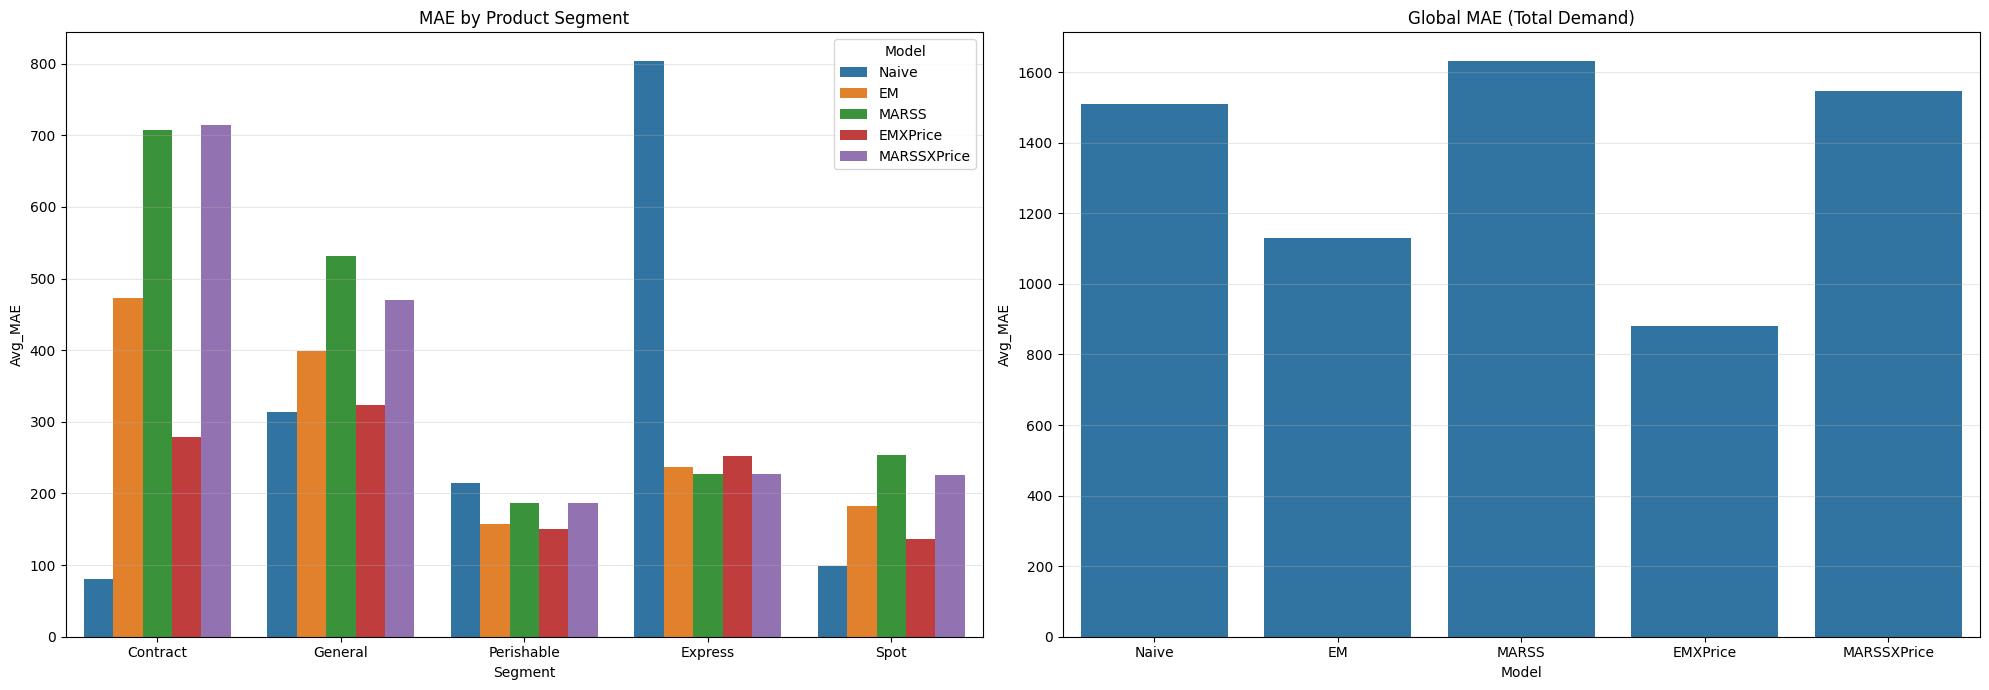

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(20, 7))

# Left: Segment MAE
sns.barplot(data=summary_df[summary_df["Segment"] != "Total"], x="Segment", y="Avg_MAE", hue="Model", ax=ax[0])
ax[0].set_title("MAE by Product Segment")
ax[0].grid(axis='y', alpha=0.3)

# Right: Global MAE
sns.barplot(data=summary_df[summary_df["Segment"] == "Total"], x="Model", y="Avg_MAE", ax=ax[1])
ax[1].set_title("Global MAE (Total Demand)")
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

No 2025 data found. Using last 365 rows instead.


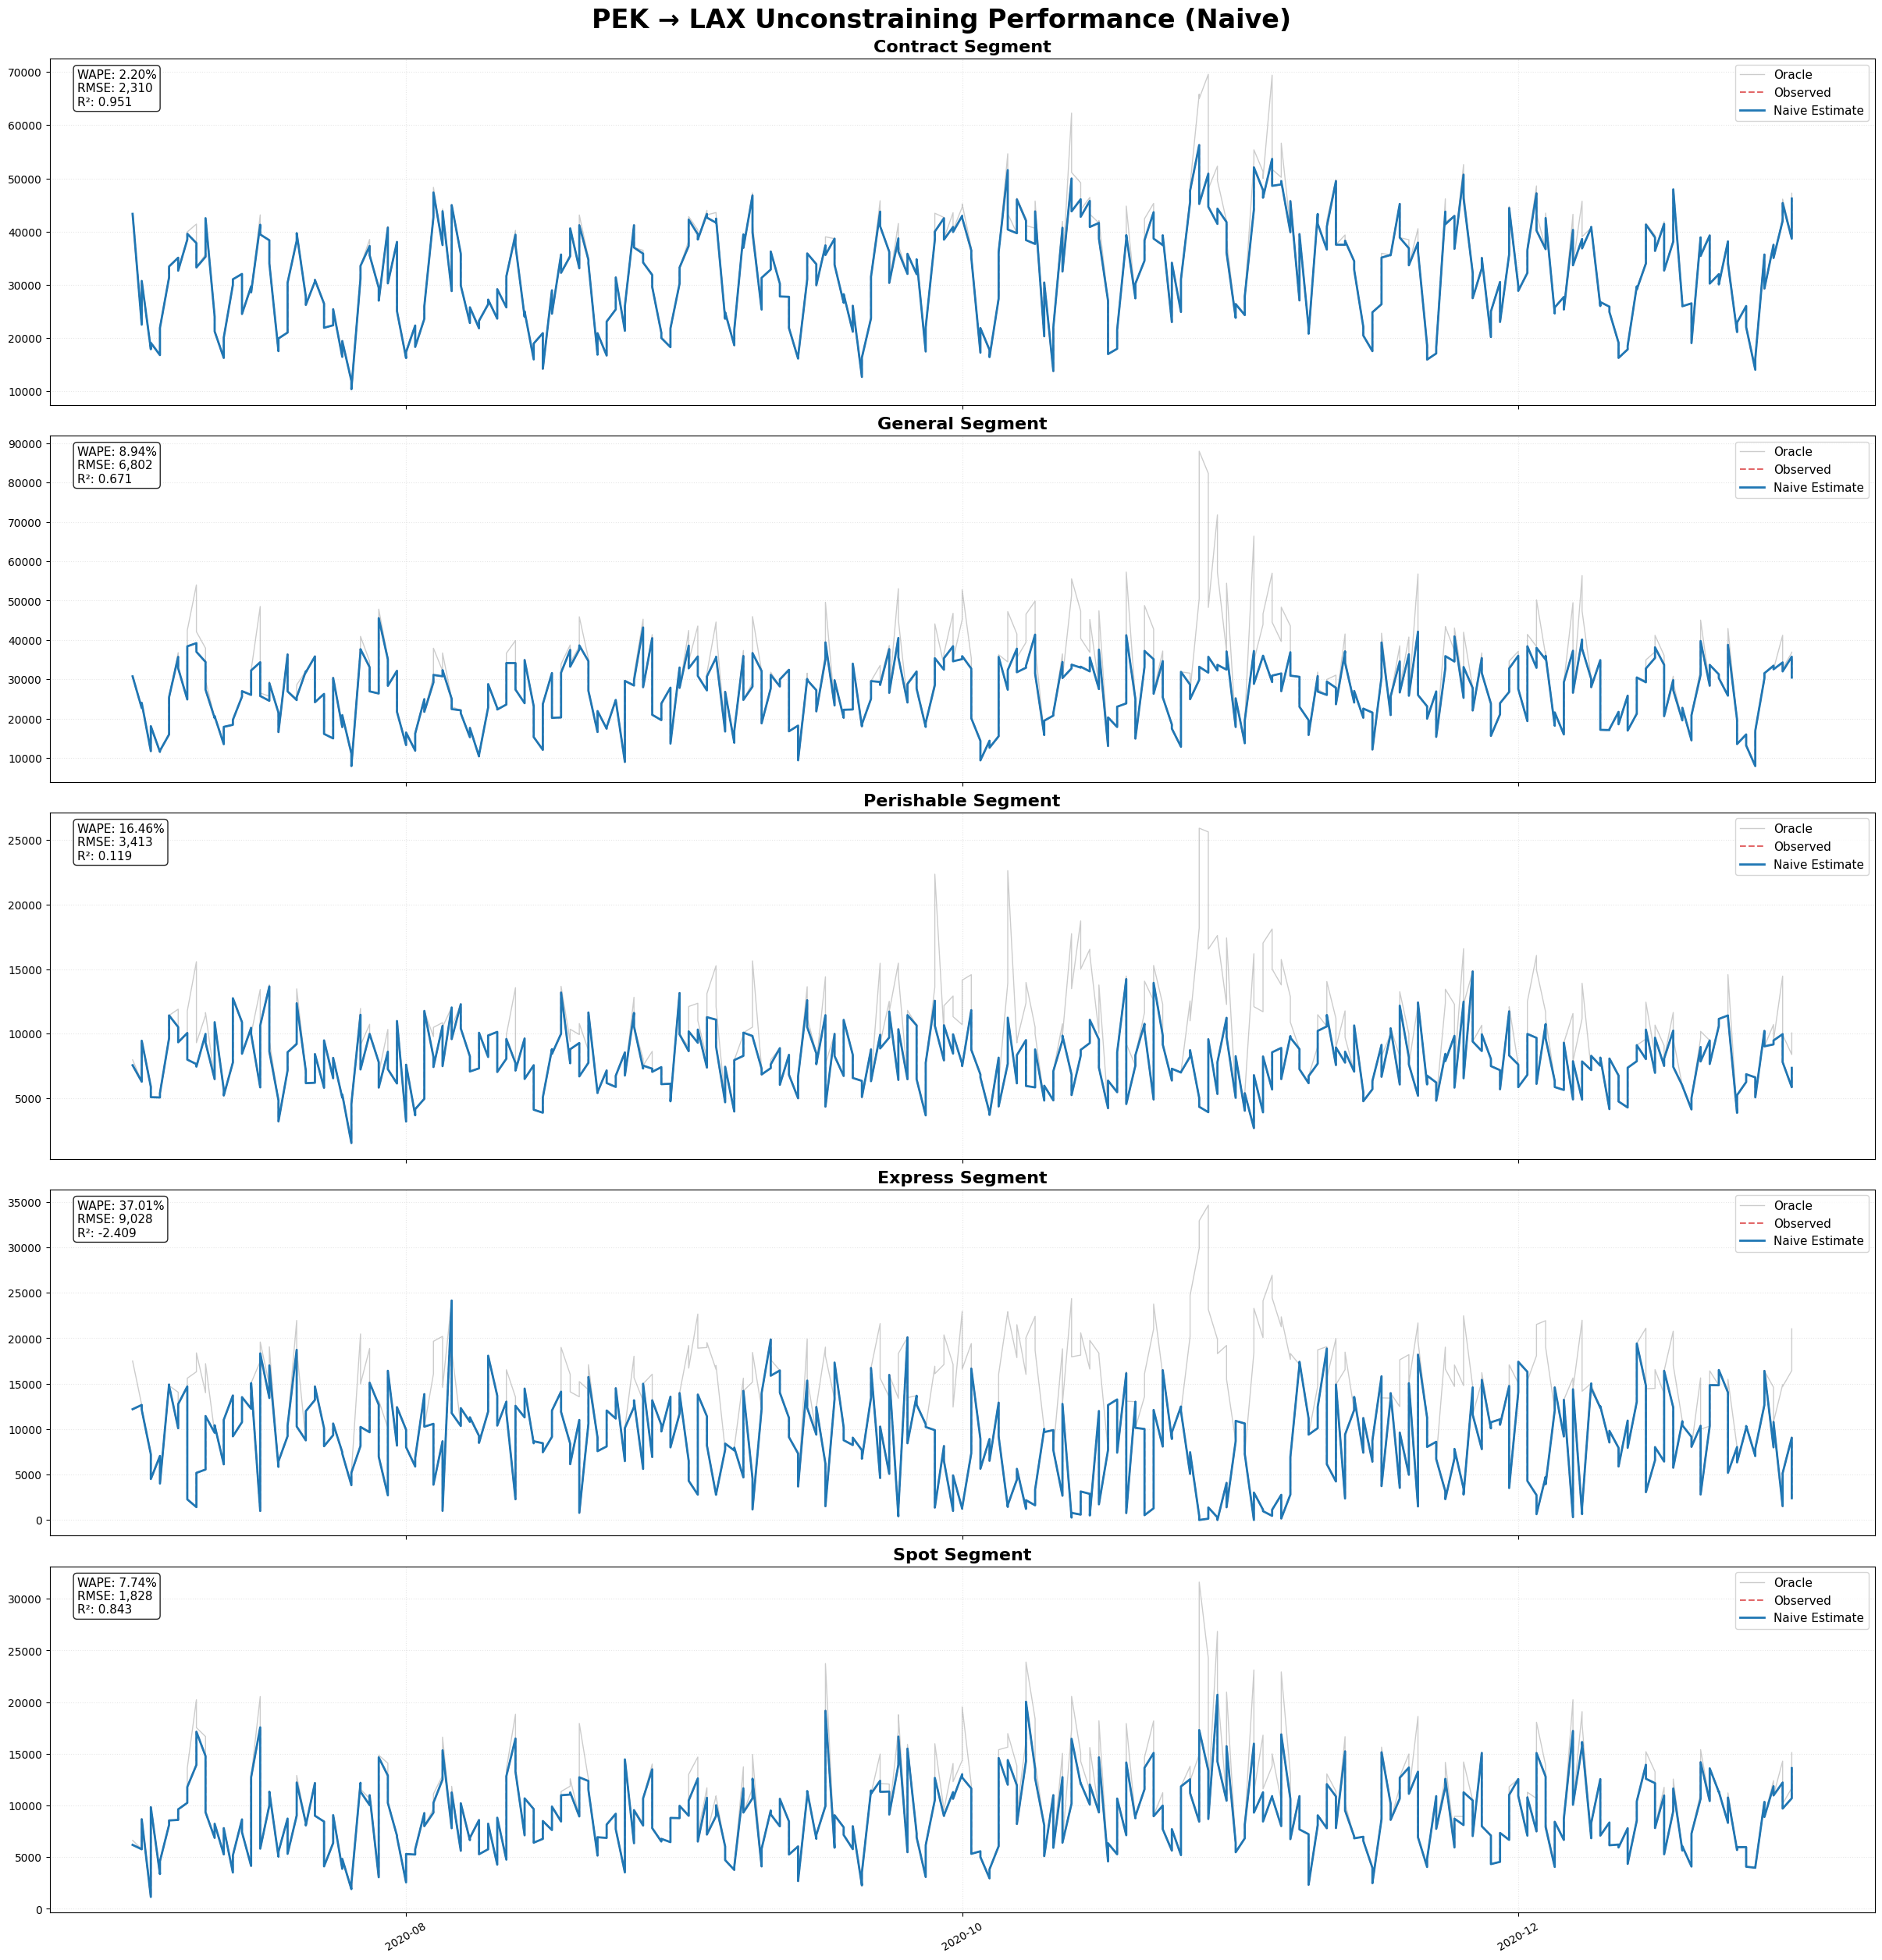

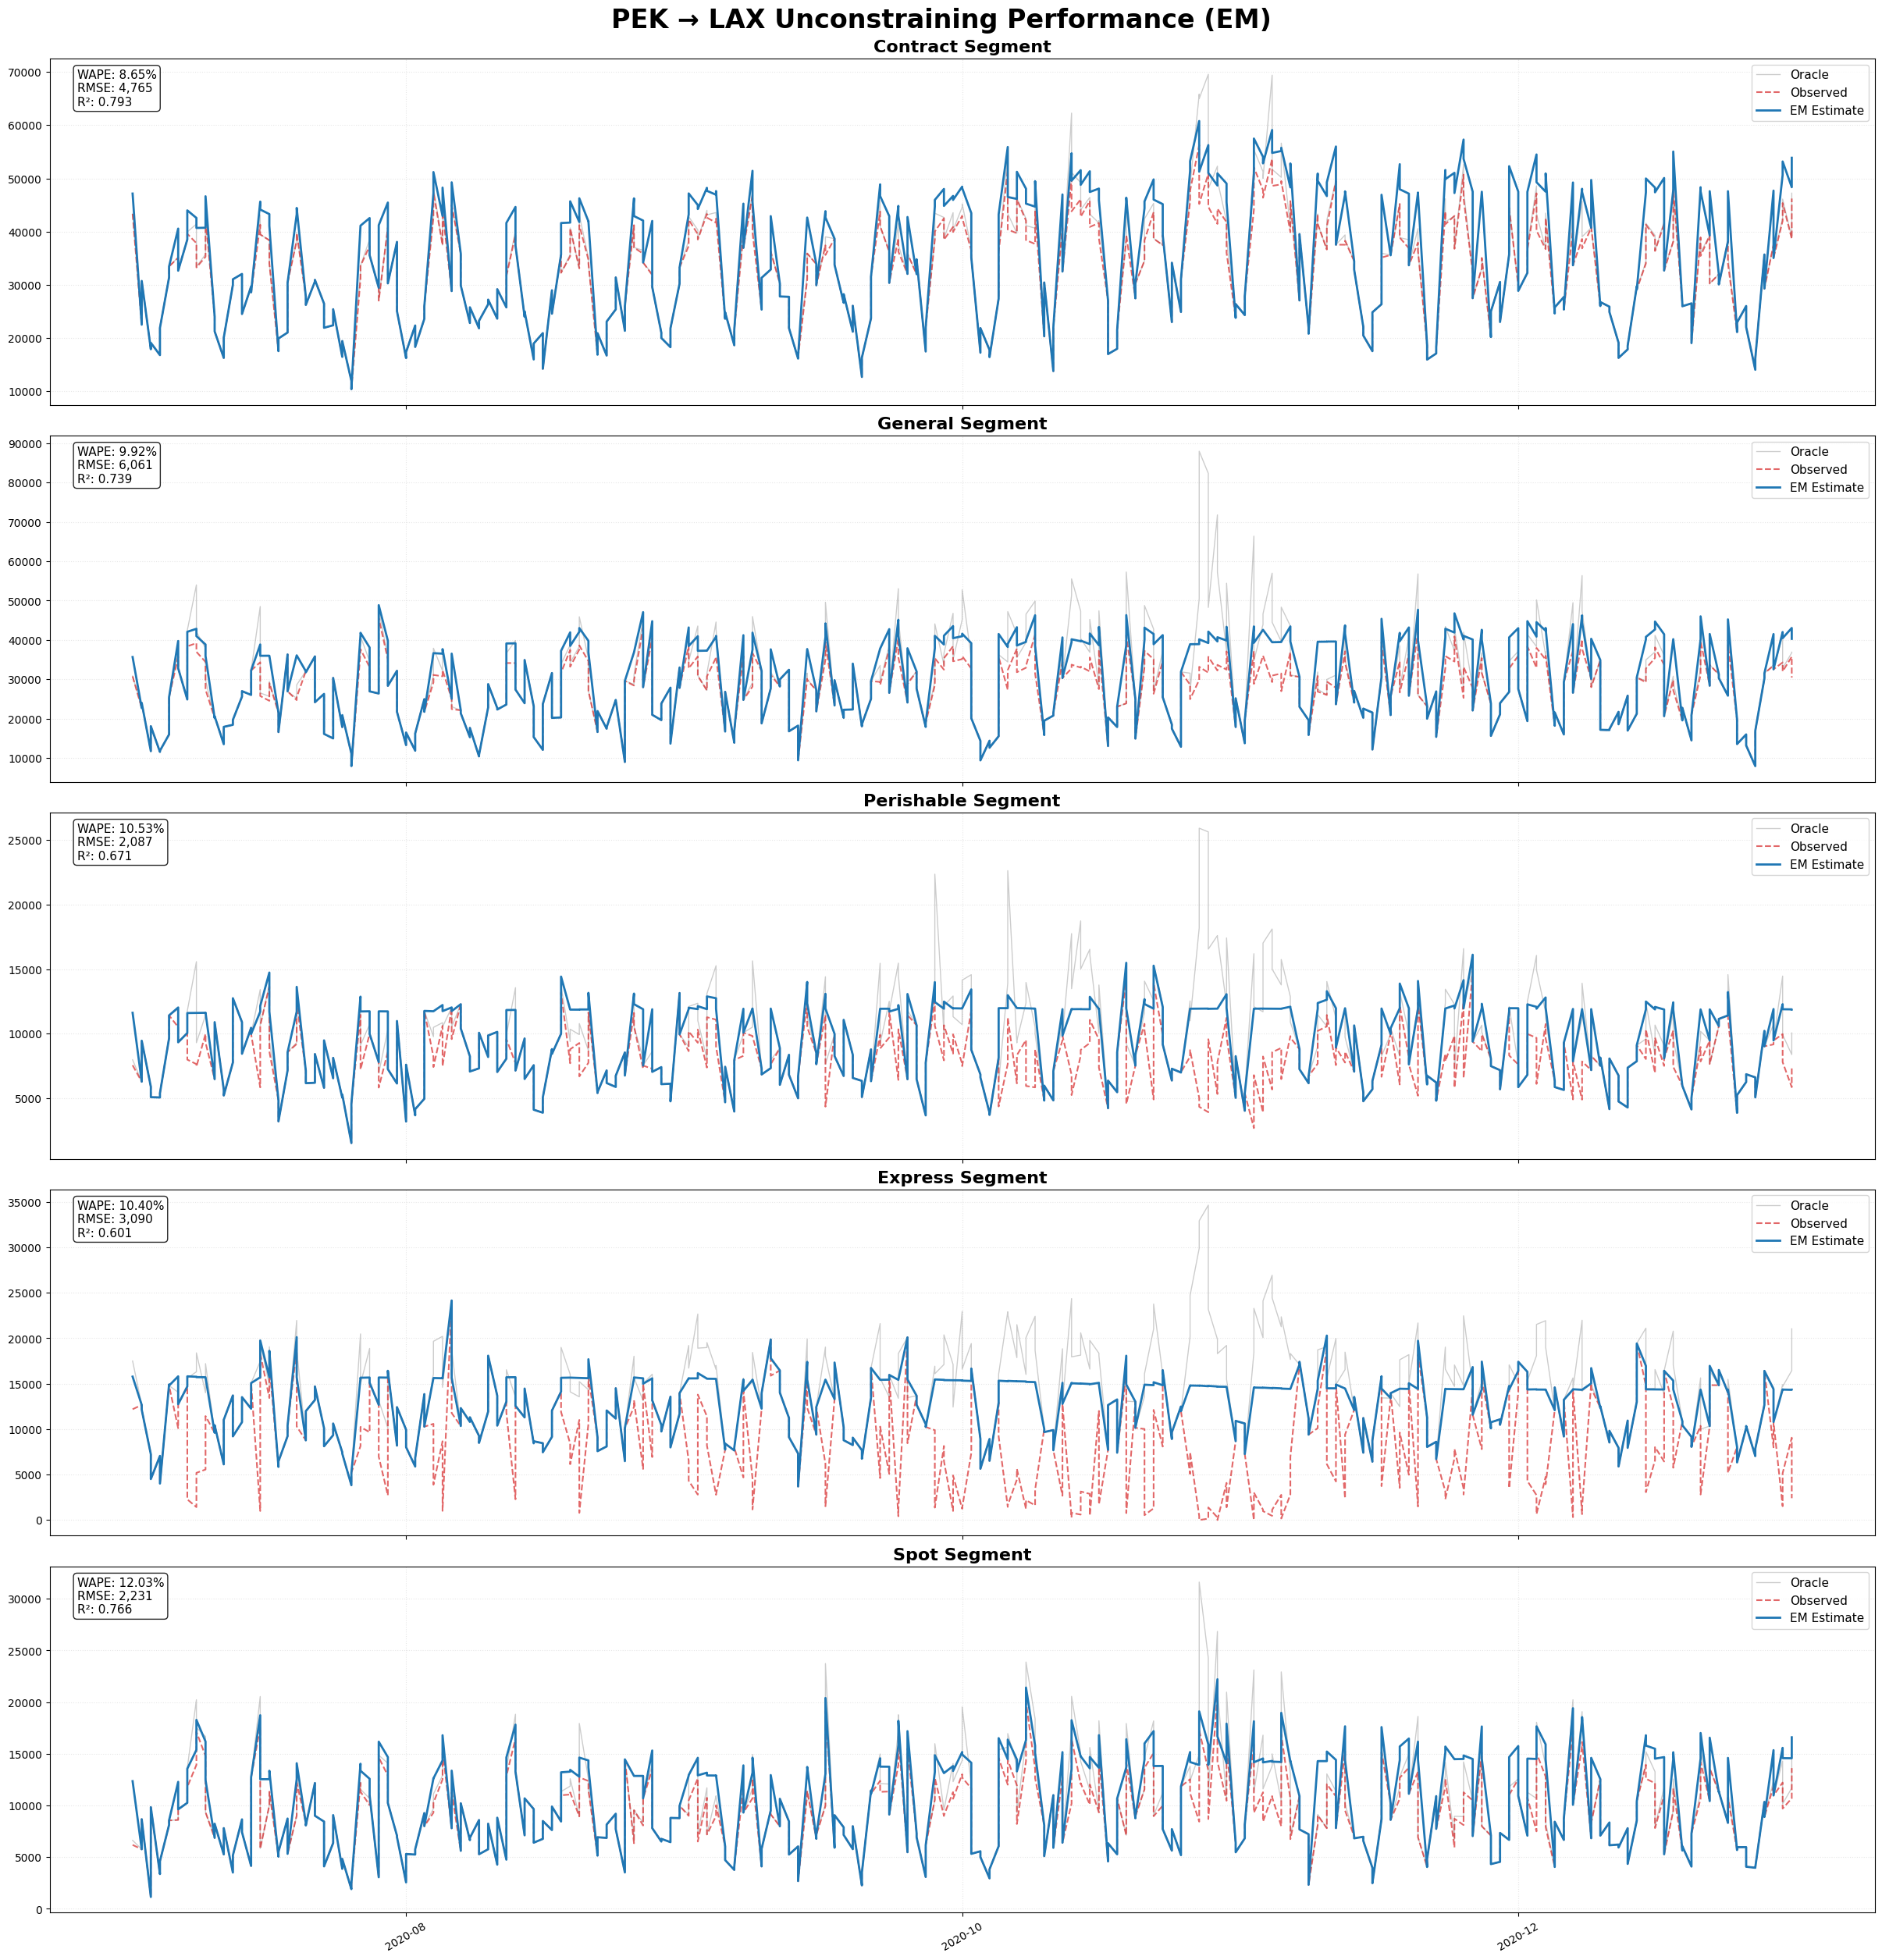

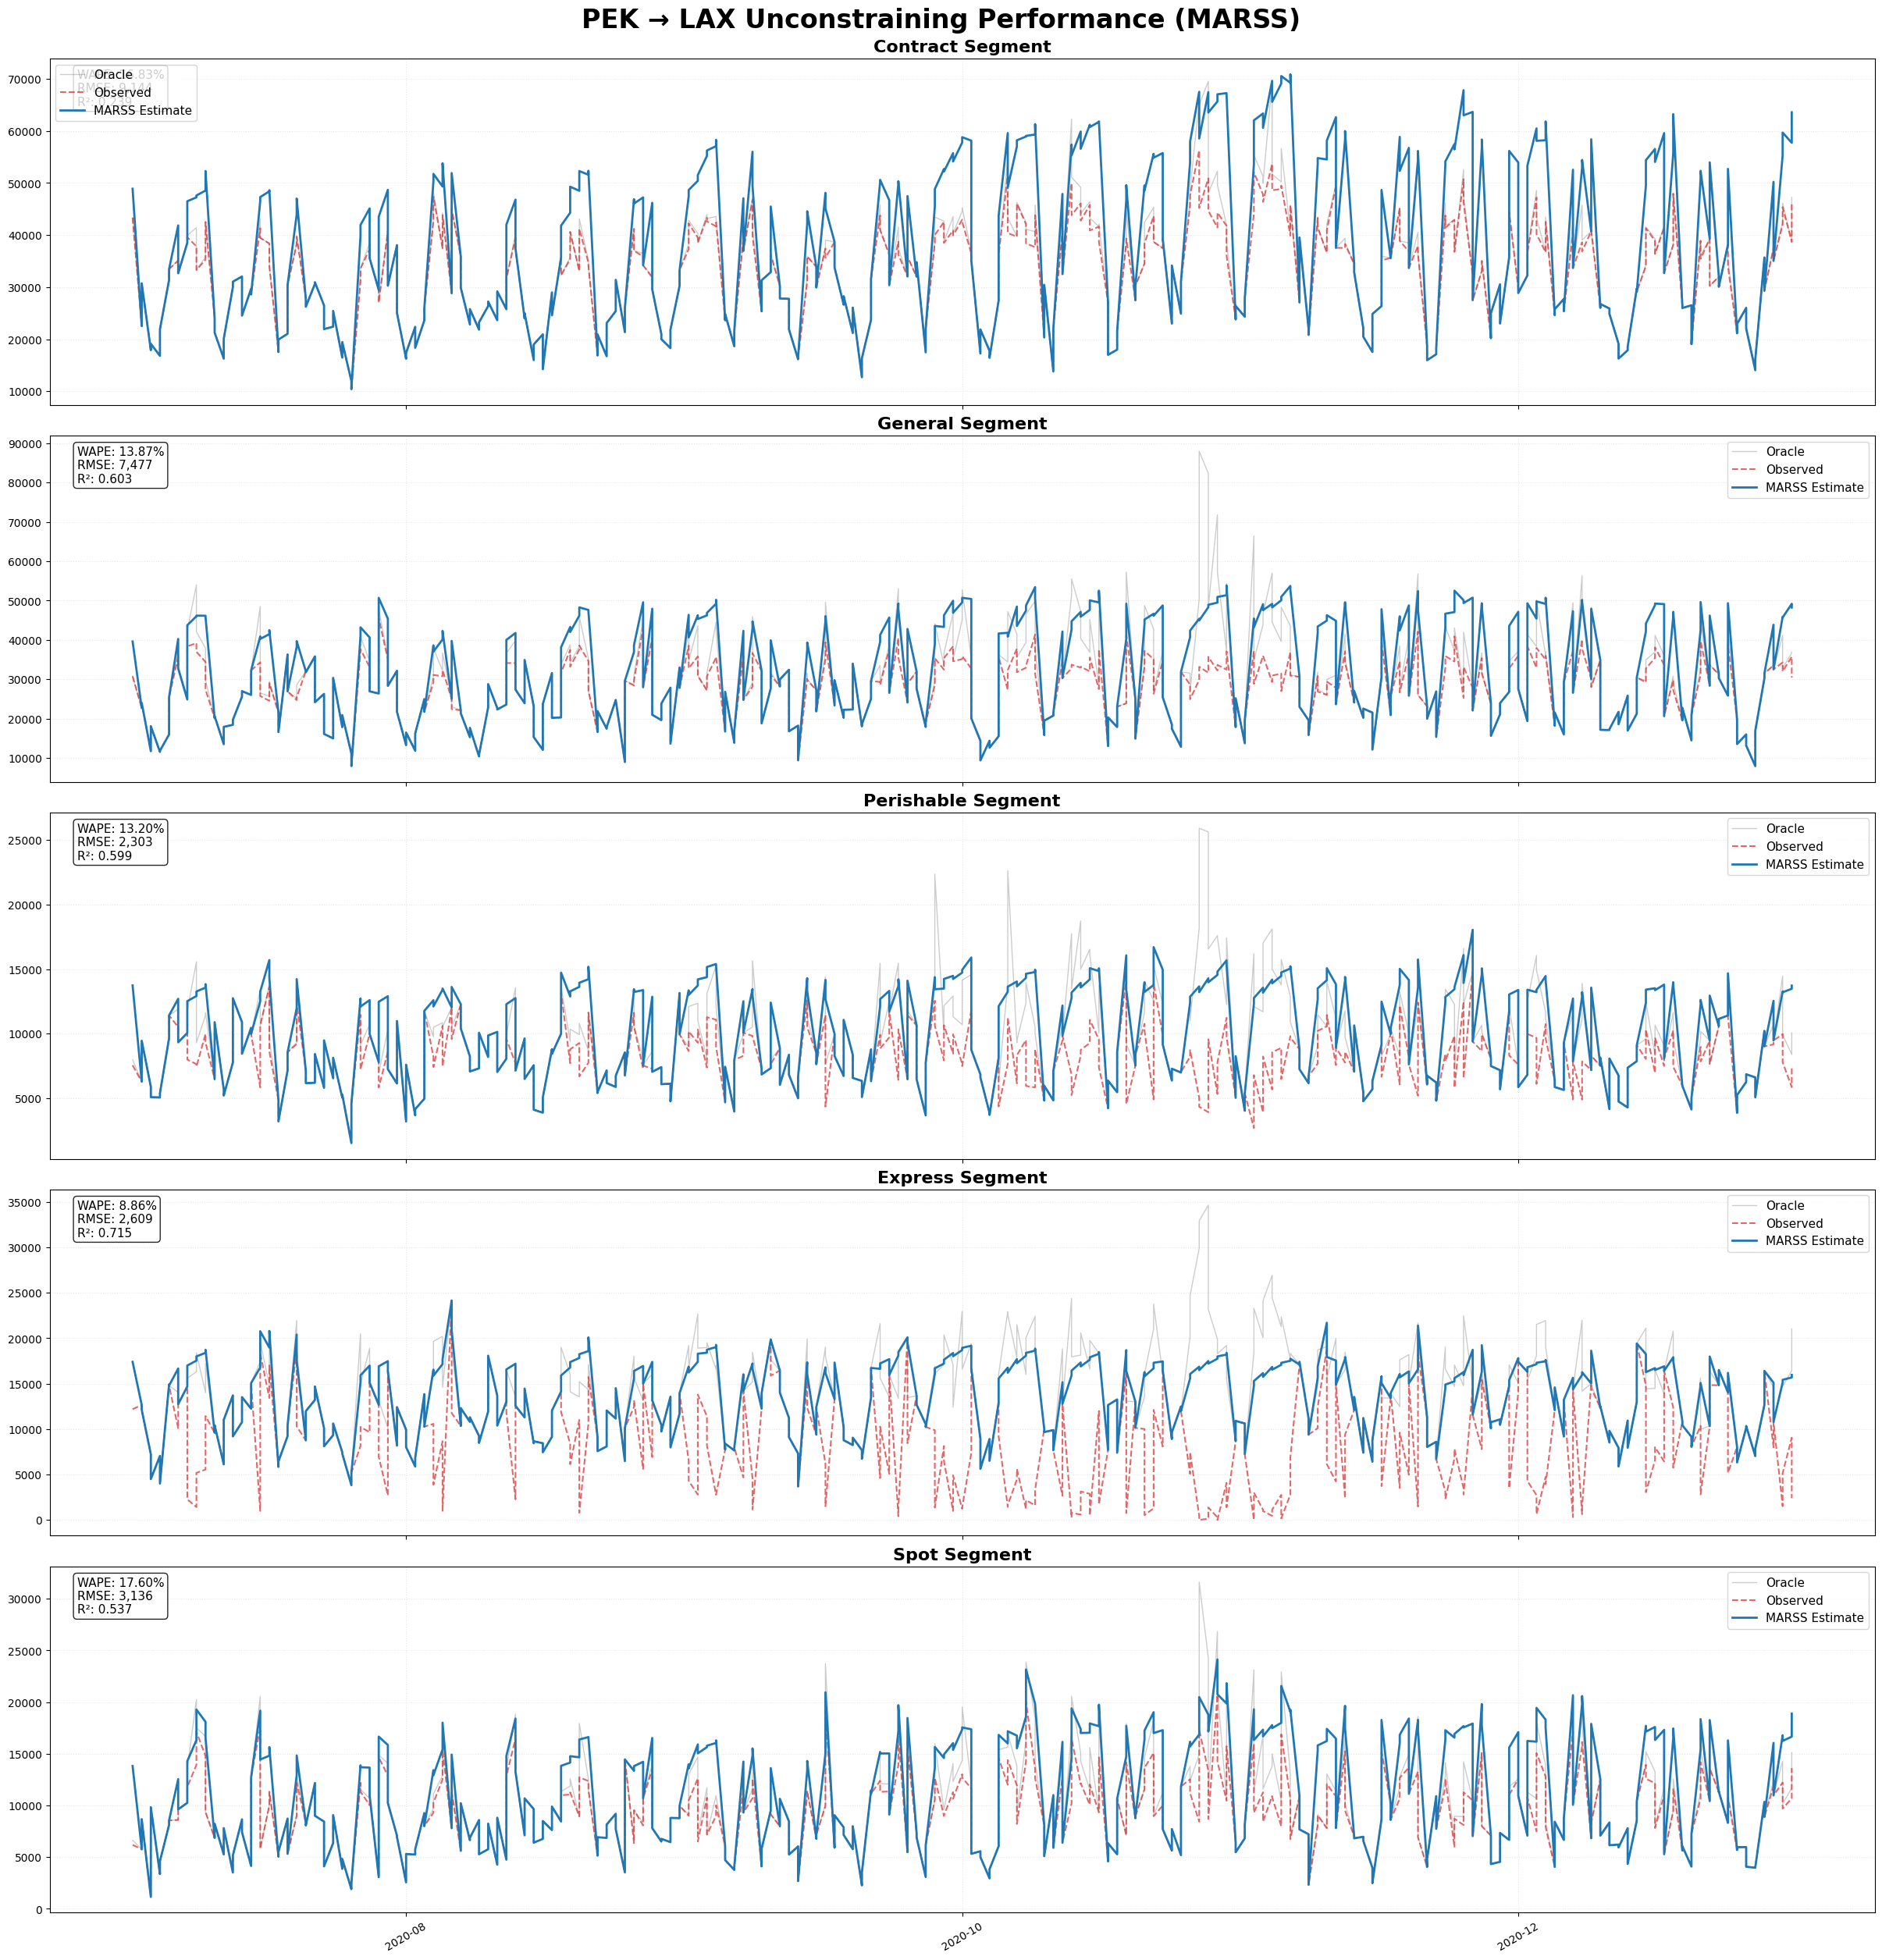

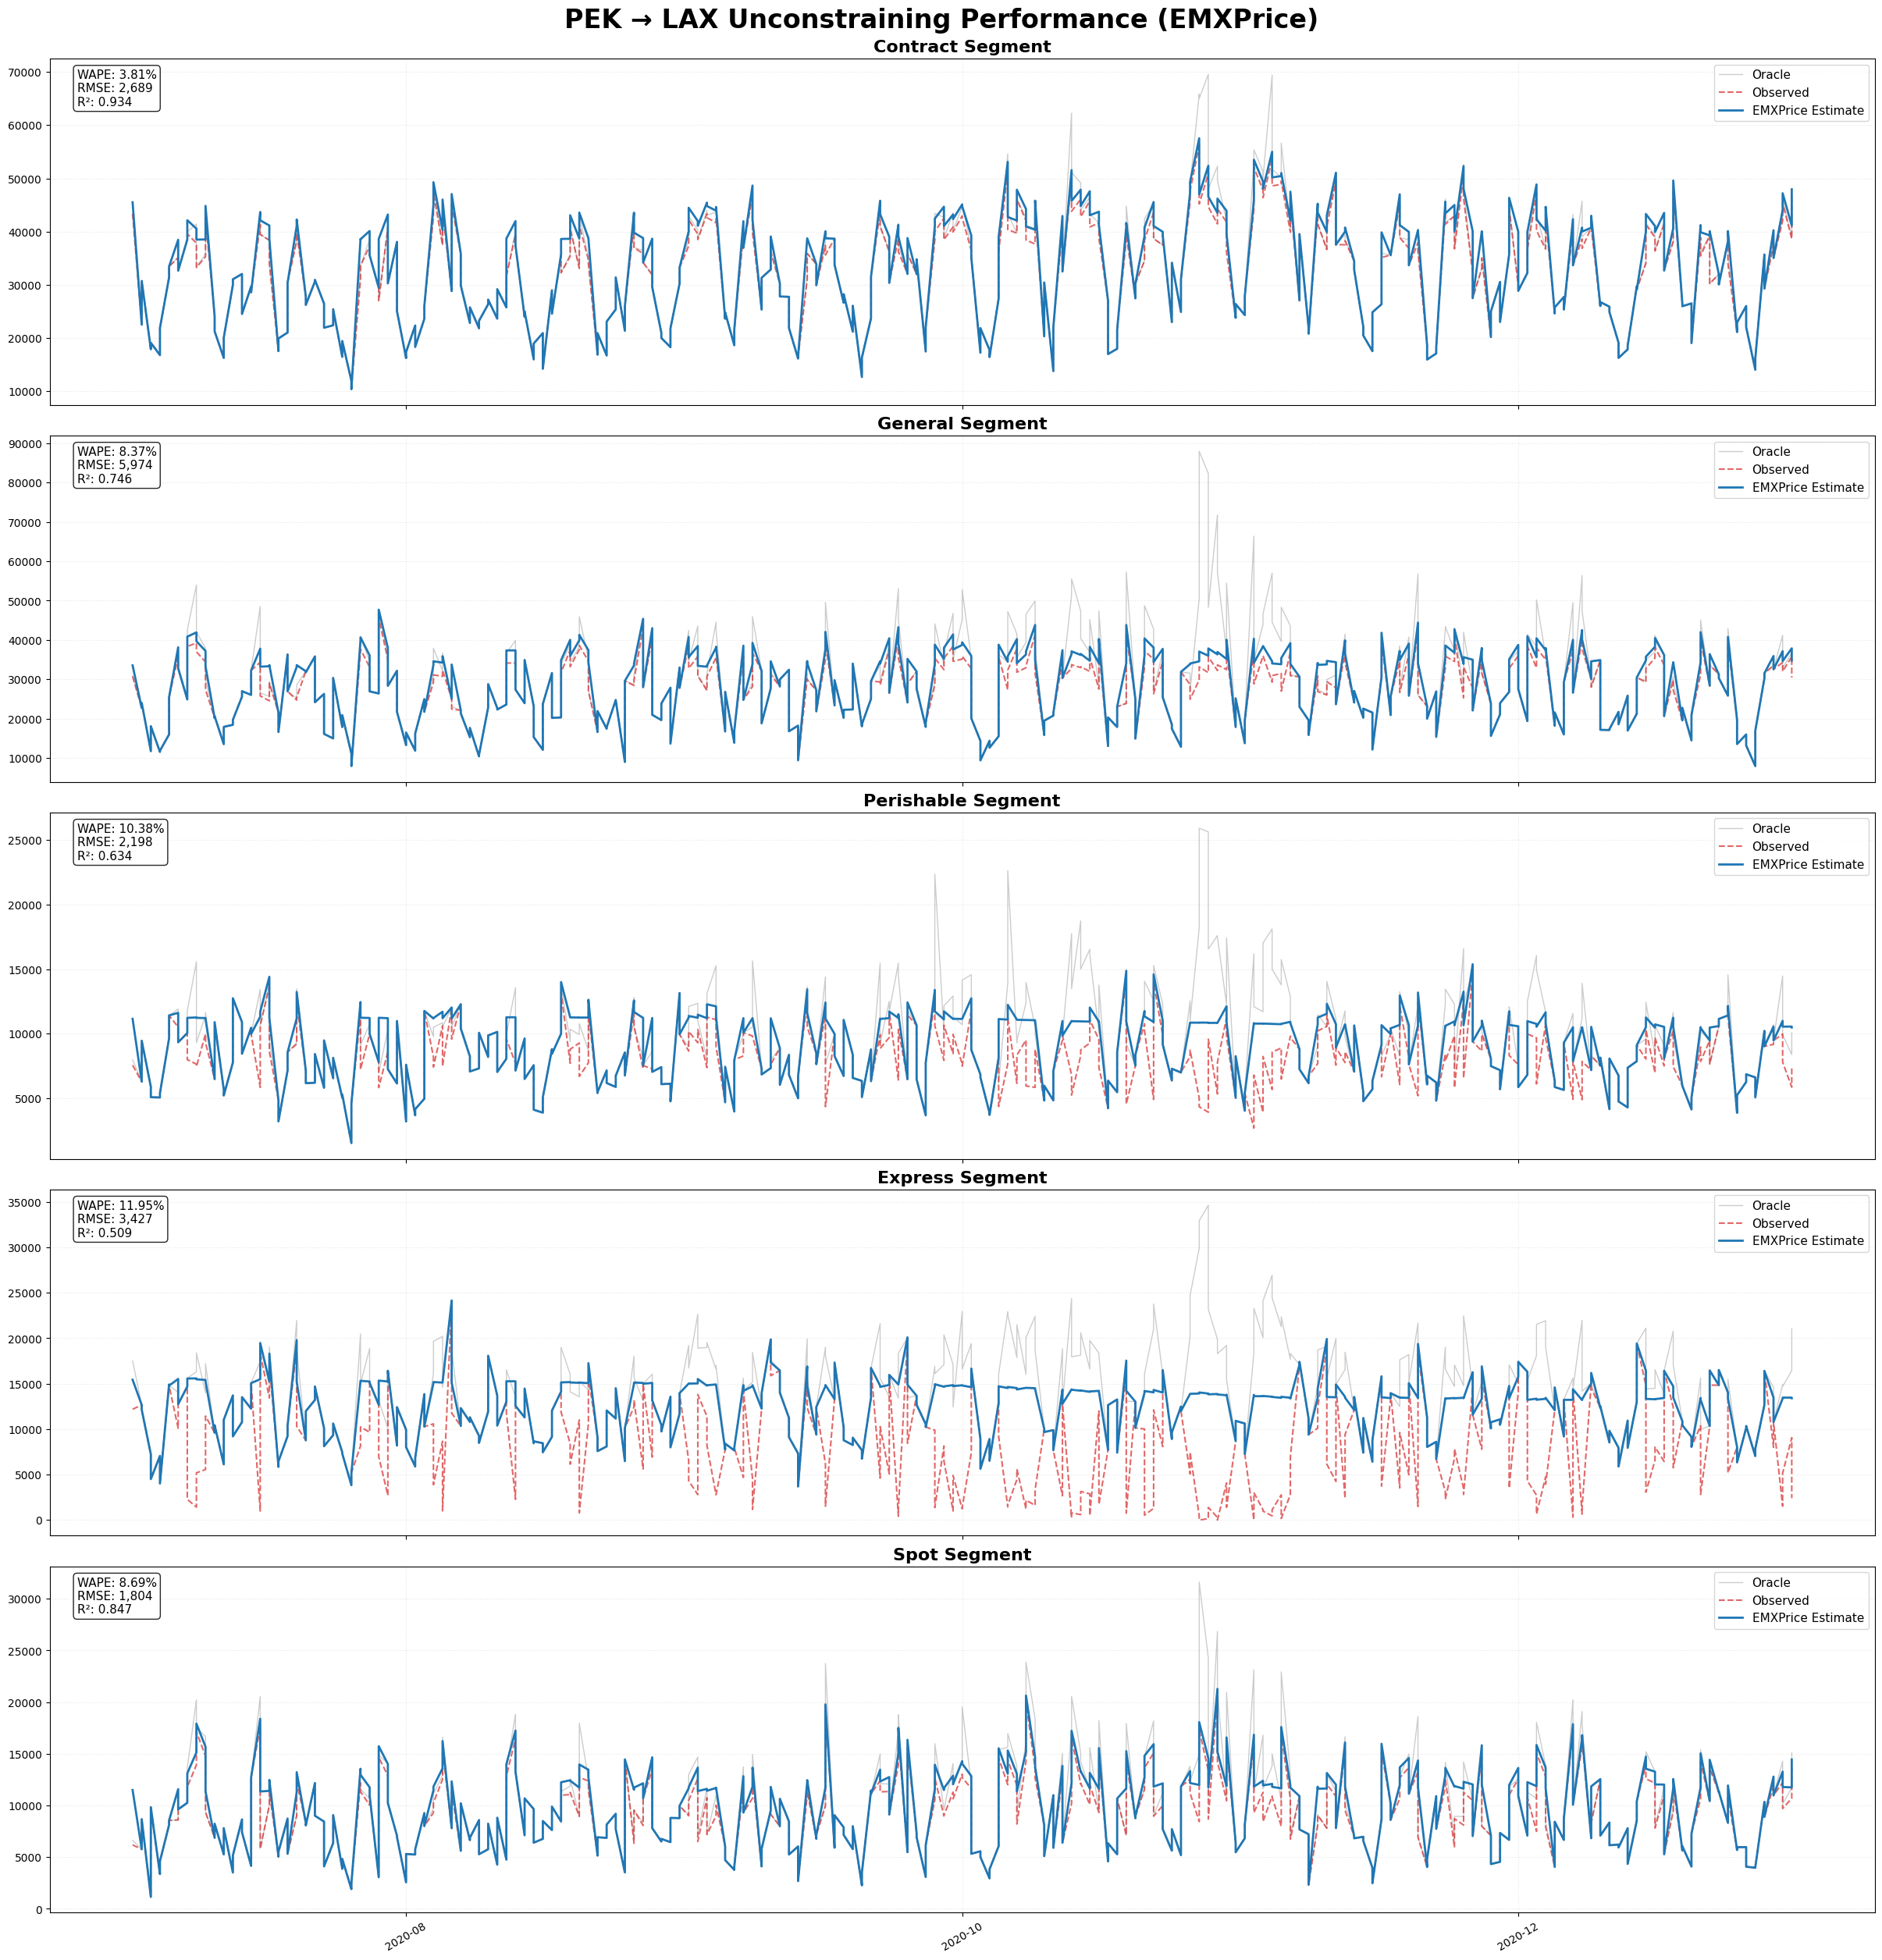

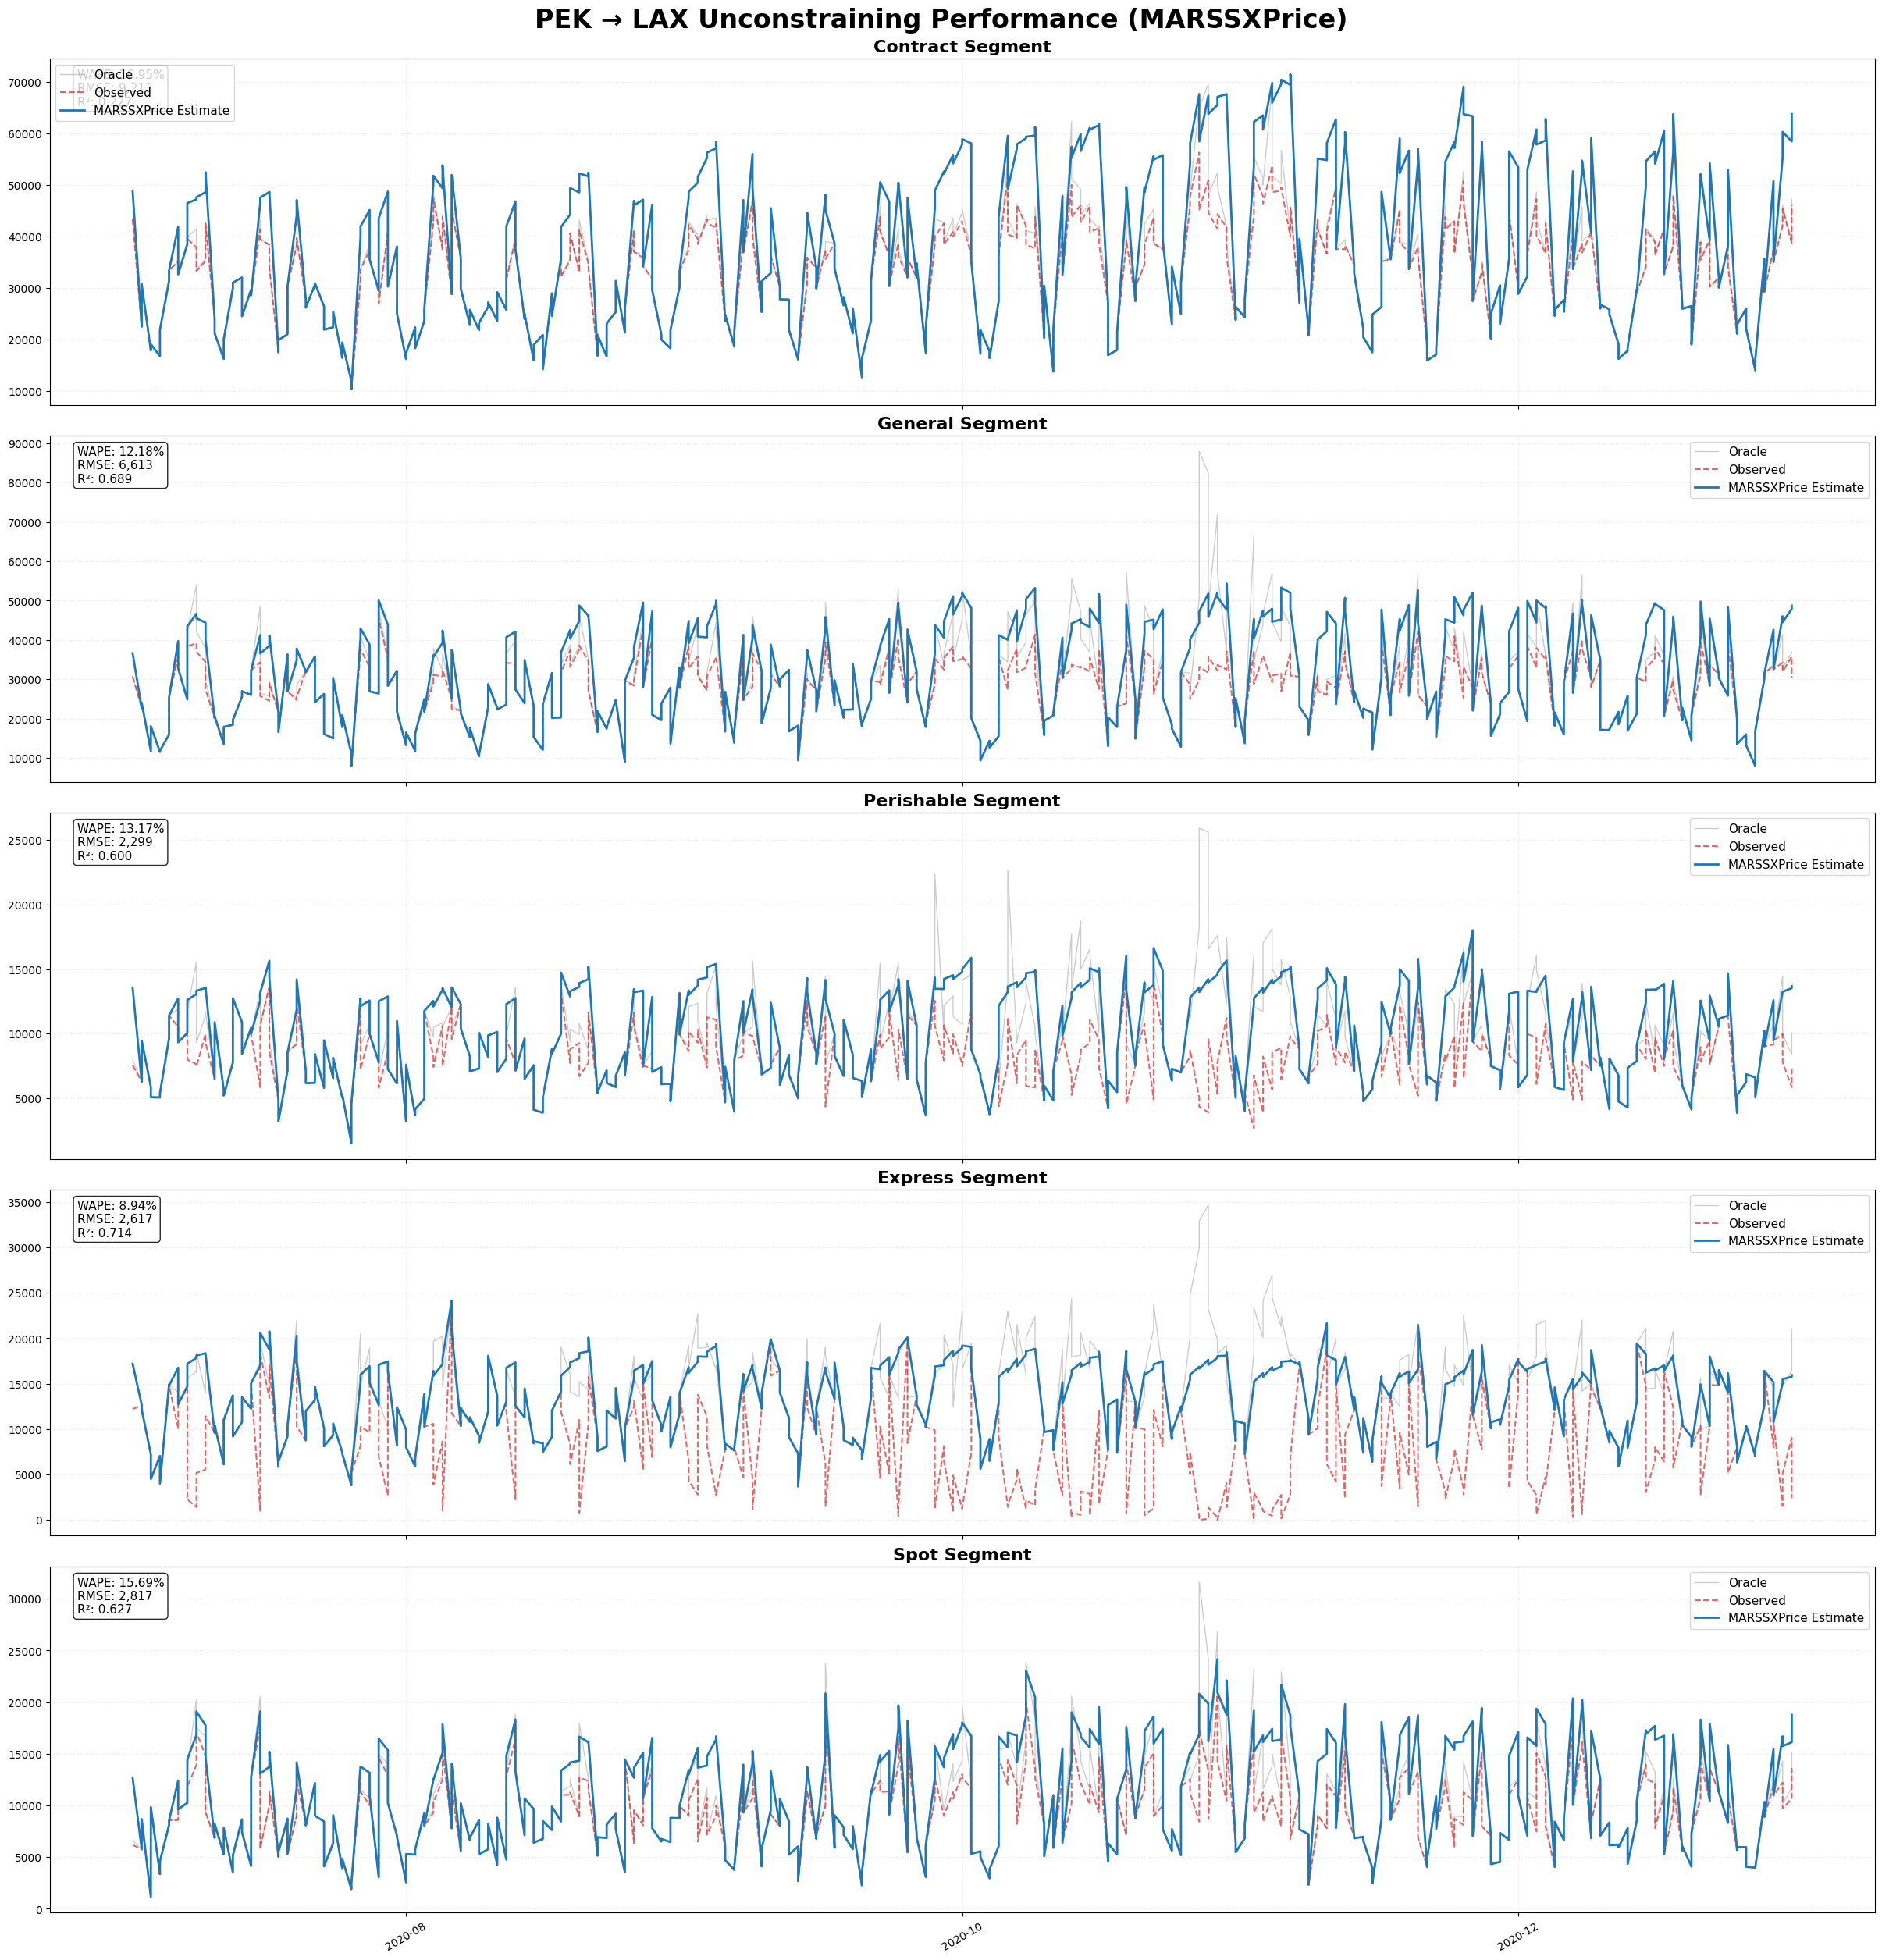

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score

# =========================================================
# FILTER DATA
# =========================================================

pek_lax = df_all[
    (df_all["Origin"] == "PEK") &
    (df_all["Destination"] == "LAX")
].copy()

pek_lax["Date"] = pd.to_datetime(pek_lax["Date"])
pek_lax = pek_lax.sort_values("Date")

# Focus on 2025
viz_slice = pek_lax[
    (pek_lax["Date"] >= "2025-01-01") &
    (pek_lax["Date"] <= "2025-12-31")
].copy()

if viz_slice.empty:
    print("No 2025 data found. Using last 365 rows instead.")
    viz_slice = pek_lax.tail(365)

# =========================================================
# PLOT ONE MODEL AT A TIME
# =========================================================

for model in MODELS:

    fig, axes = plt.subplots(
        len(SEGMENTS),
        1,
        figsize=(24, 5 * len(SEGMENTS)),
        sharex=True,
        constrained_layout=True
    )

    # Edge case: only one segment
    if len(SEGMENTS) == 1:
        axes = [axes]

    for i, seg in enumerate(SEGMENTS):

        ax = axes[i]

        oracle_col = f"Oracle_{seg}_kg"
        obs_col = f"Observed_{seg}_kg"
        est_col = f"{model}_{seg}_Est"

        # =================================================
        # DATA
        # =================================================

        y_true = viz_slice[oracle_col].values
        y_obs  = viz_slice[obs_col].values
        y_pred = viz_slice[est_col].values

        # =================================================
        # METRICS
        # =================================================

        mae = np.mean(np.abs(y_true - y_pred))

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        wape = (
            np.sum(np.abs(y_true - y_pred))
            / np.sum(np.abs(y_true))
        ) * 100

        r2 = r2_score(y_true, y_pred)

        metric_text = (
            f"WAPE: {wape:.2f}%\n"
            f"RMSE: {rmse:,.0f}\n"
            f"R²: {r2:.3f}"
        )

        # =================================================
        # PLOTS
        # =================================================

        # Oracle (ground truth)
        ax.plot(
            viz_slice["Date"],
            y_true,
            label="Oracle",
            color="gray",
            alpha=0.4,
            linewidth=1
        )

        # Observed (censored input)
        ax.plot(
            viz_slice["Date"],
            y_obs,
            label="Observed",
            color="tab:red",
            linestyle="--",
            alpha=0.7,
            linewidth=1.5
        )

        # Estimated (model output)
        ax.plot(
            viz_slice["Date"],
            y_pred,
            label=f"{model} Estimate",
            color="tab:blue",
            linewidth=2
        )

        # =================================================
        # STYLING
        # =================================================

        ax.set_title(
            f"{seg} Segment",
            fontsize=16,
            fontweight='bold'
        )

        ax.grid(True, linestyle=':', alpha=0.3)

        ax.legend(fontsize=11)

        # Date formatting
        ax.xaxis.set_major_locator(
            mdates.MonthLocator(interval=2)
        )

        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%Y-%m')
        )

        ax.tick_params(axis='x', rotation=30)

        # =================================================
        # METRIC BOX
        # =================================================

        ax.text(
            0.015,
            0.97,
            metric_text,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.85
            )
        )

    # =====================================================
    # FIGURE TITLE
    # =====================================================

    fig.suptitle(
        f"PEK → LAX Unconstraining Performance ({model})",
        fontsize=24,
        fontweight='bold'
    )

    plt.show()